# Meteorology Final Project Solution

This notebook shows one complete solution for cleaning and analyzing a large daily weather dataset from 2012 to 2023.


## Outline

1. Load the raw files.
2. Inspect missing values, bad types, and duplicates.
3. Clean each station dataset.
4. Combine the cleaned data.
5. Use aggregation to test the climate claims.
6. Plot monthly summaries for readable comparisons.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


## Load the raw files


In [28]:
port_aurora_raw = pd.read_csv("data/meteorology/port_aurora.csv")
sunspire_raw = pd.read_csv("data/meteorology/sunspire_dune.tsv", sep="\t")
frostholm_raw = pd.read_excel("data/meteorology/frostholm_ridge.xlsx")

print(port_aurora_raw.shape, sunspire_raw.shape, frostholm_raw.shape)


(4386, 5) (4383, 5) (4383, 5)


## Quick inspection

Because the data is large, we inspect it with summaries instead of trying to read every row manually.


In [29]:
for name, df in {
    "Port Aurora": port_aurora_raw,
    "Sunspire Dune": sunspire_raw,
    "Frostholm Ridge": frostholm_raw,
}.items():
    print(f"\n{name}")
    print("shape", df.shape)
    print(df.head(3))
    print(df.dtypes)
    print("missing values")
    print(df.isna().sum())
    print("duplicate rows", df.duplicated().sum())



Port Aurora
shape (4386, 5)
  observation_day  station_label  avg_temp_c  mean_pressure_hpa total_rain_mm
0      2012/01/01   Port Aurora          6.5             1010.7          15.9
1      2012/01/02   Port Aurora          6.5             1010.7          15.9
2      2012/01/03   Port Aurora          6.6             1010.8          15.9
observation_day          str
station_label            str
avg_temp_c           float64
mean_pressure_hpa    float64
total_rain_mm            str
dtype: object
missing values
observation_day      0
station_label        0
avg_temp_c           1
mean_pressure_hpa    0
total_rain_mm        0
dtype: int64
duplicate rows 3

Sunspire Dune
shape (4383, 5)
     obs_date        station  air_temp_c pressure_reading  daily_rain_mm
0  01-01-2012  Sunspire Dune        20.1           1010.2           0.08
1  02-01-2012  Sunspire Dune        20.1           1010.2           0.08
2  03-01-2012  Sunspire Dune        20.2           1010.3           0.09
obs_date         

## Clean Port Aurora

This file contains duplicate rows, inconsistent station labels, one missing temperature value, and a rainfall value stored as text.


In [30]:
port_aurora = port_aurora_raw.copy()
port_aurora = port_aurora.rename(
    columns={
        "observation_day": "date",
        "station_label": "station",
        "avg_temp_c": "temperature_c",
        "mean_pressure_hpa": "pressure_hpa",
        "total_rain_mm": "rain_mm",
    }
)
port_aurora["date"] = pd.to_datetime(port_aurora["date"], format="%Y/%m/%d")
port_aurora["station"] = (
    port_aurora["station"]
    .astype(str)
    .str.strip()
    .replace({"port aurora": "Port Aurora"})
)
for column in ["temperature_c", "pressure_hpa", "rain_mm"]:
    port_aurora[column] = pd.to_numeric(port_aurora[column], errors="coerce")

print("duplicate rows before cleaning:", port_aurora.duplicated().sum())
port_aurora = port_aurora.drop_duplicates().sort_values("date")

for column in ["temperature_c", "pressure_hpa", "rain_mm"]:
    port_aurora[column] = port_aurora[column].fillna(port_aurora[column].median())

port_aurora = port_aurora.reset_index(drop=True)
port_aurora.head()


duplicate rows before cleaning: 3


,date,station,temperature_c,pressure_hpa,rain_mm
0,2012-01-01,Port Aurora,6.5,1010.7,15.9
1,2012-01-02,Port Aurora,6.5,1010.7,15.9
2,2012-01-03,Port Aurora,6.6,1010.8,15.9
3,2012-01-04,Port Aurora,6.6,1010.8,15.8
4,2012-01-05,Port Aurora,6.6,1010.8,15.7


## Clean Sunspire Dune

The desert station uses a TSV export, a different date format, and a bad pressure value stored as text.


In [31]:
sunspire = sunspire_raw.copy()
sunspire = sunspire.rename(
    columns={
        "obs_date": "date",
        "station": "station",
        "air_temp_c": "temperature_c",
        "pressure_reading": "pressure_hpa",
        "daily_rain_mm": "rain_mm",
    }
)
sunspire["date"] = pd.to_datetime(sunspire["date"], format="%d-%m-%Y")
sunspire["station"] = (
    sunspire["station"]
    .astype(str)
    .str.strip()
    .replace({"sunspire dune": "Sunspire Dune"})
)
for column in ["temperature_c", "pressure_hpa", "rain_mm"]:
    sunspire[column] = pd.to_numeric(sunspire[column], errors="coerce")
    sunspire[column] = sunspire[column].fillna(sunspire[column].median())

print("duplicate rows before cleaning:", sunspire.duplicated().sum())
sunspire = sunspire.drop_duplicates().sort_values("date").reset_index(drop=True)
sunspire.head()


duplicate rows before cleaning: 0


,date,station,temperature_c,pressure_hpa,rain_mm
0,2012-01-01,Sunspire Dune,20.1,1010.2,0.08
1,2012-01-02,Sunspire Dune,20.1,1010.2,0.08
2,2012-01-03,Sunspire Dune,20.2,1010.3,0.09
3,2012-01-04,Sunspire Dune,20.2,1010.3,0.09
4,2012-01-05,Sunspire Dune,20.2,1010.3,0.09


## Clean Frostholm Ridge

The Excel file loads the dates well, but it still contains one text value in the temperature column and one missing pressure value.


In [32]:
frostholm = frostholm_raw.copy()
frostholm = frostholm.rename(
    columns={
        "Date Recorded": "date",
        "Location": "station",
        "Temperature (C)": "temperature_c",
        "Pressure_hPa": "pressure_hpa",
        "Rainfall_mm": "rain_mm",
    }
)
frostholm["date"] = pd.to_datetime(frostholm["date"])
frostholm["station"] = frostholm["station"].astype(str).str.strip()
for column in ["temperature_c", "pressure_hpa", "rain_mm"]:
    frostholm[column] = pd.to_numeric(frostholm[column], errors="coerce")
    frostholm[column] = frostholm[column].fillna(frostholm[column].median())

print("duplicate rows before cleaning:", frostholm.duplicated().sum())
frostholm = frostholm.drop_duplicates().sort_values("date").reset_index(drop=True)
frostholm.head()


duplicate rows before cleaning: 0


,date,station,temperature_c,pressure_hpa,rain_mm
0,2012-01-01,Frostholm Ridge,-16.9,1003.7,5.5
1,2012-01-02,Frostholm Ridge,-16.9,1003.8,5.5
2,2012-01-03,Frostholm Ridge,-16.8,1003.8,5.5
3,2012-01-04,Frostholm Ridge,-16.8,1003.9,5.4
4,2012-01-05,Frostholm Ridge,-16.7,1003.9,5.4


## Confirm the cleaned schemas


In [33]:
for name, df in {
    "Port Aurora": port_aurora,
    "Sunspire Dune": sunspire,
    "Frostholm Ridge": frostholm,
}.items():
    print(f"\n{name}")
    print(df.columns.tolist())
    print(df.dtypes)
    print(df.shape)



Port Aurora
['date', 'station', 'temperature_c', 'pressure_hpa', 'rain_mm']
date             datetime64[us]
station                     str
temperature_c           float64
pressure_hpa            float64
rain_mm                 float64
dtype: object
(4383, 5)

Sunspire Dune
['date', 'station', 'temperature_c', 'pressure_hpa', 'rain_mm']
date             datetime64[us]
station                     str
temperature_c           float64
pressure_hpa            float64
rain_mm                 float64
dtype: object
(4383, 5)

Frostholm Ridge
['date', 'station', 'temperature_c', 'pressure_hpa', 'rain_mm']
date             datetime64[us]
station                     str
temperature_c           float64
pressure_hpa            float64
rain_mm                 float64
dtype: object
(4383, 5)


## Combine the cleaned data


In [34]:
weather_df = pd.concat([port_aurora, sunspire, frostholm], ignore_index=True)
weather_df = weather_df.sort_values(["station", "date"]).reset_index(drop=True)
weather_df.head()


,date,station,temperature_c,pressure_hpa,rain_mm
0,2012-01-01,Frostholm Ridge,-16.9,1003.7,5.5
1,2012-01-02,Frostholm Ridge,-16.9,1003.8,5.5
2,2012-01-03,Frostholm Ridge,-16.8,1003.8,5.5
3,2012-01-04,Frostholm Ridge,-16.8,1003.9,5.4
4,2012-01-05,Frostholm Ridge,-16.7,1003.9,5.4


In [35]:
print(weather_df.shape)
print(weather_df.groupby("station").size())


(13149, 5)
station
Frostholm Ridge    4383
Port Aurora        4383
Sunspire Dune      4383
dtype: int64


## Build evidence with aggregation

The raw daily table is too large to interpret directly, so we compute grouped summaries.


In [36]:
summary_stats = weather_df.groupby("station").agg(
    avg_temperature_c=("temperature_c", "mean"),
    min_temperature_c=("temperature_c", "min"),
    max_temperature_c=("temperature_c", "max"),
    temperature_std_c=("temperature_c", "std"),
    avg_pressure_hpa=("pressure_hpa", "mean"),
    total_rain_mm=("rain_mm", "sum"),
).round(2)
summary_stats["temperature_range_c"] = (
    summary_stats["max_temperature_c"] - summary_stats["min_temperature_c"]
).round(2)
summary_stats = summary_stats[
    [
        "avg_temperature_c",
        "avg_pressure_hpa",
        "total_rain_mm",
        "temperature_std_c",
        "temperature_range_c",
        "min_temperature_c",
        "max_temperature_c",
    ]
]
summary_stats


,avg_temperature_c,avg_pressure_hpa,total_rain_mm,temperature_std_c,temperature_range_c,min_temperature_c,max_temperature_c
station,,,,,,,
Frostholm Ridge,-4.72,999.10,17257.9,8.83,30.8,-22.2,8.6
Port Aurora,11.47,1015.46,42465.7,3.72,12.7,5.1,17.8
Sunspire Dune,29.62,1008.21,976.0,6.98,21.5,19.1,40.6


The grouped statistics support the main claims:

- **Port Aurora** is the wettest station and the most temperature-stable.
- **Sunspire Dune** is the hottest and driest station.
- **Frostholm Ridge** has the lowest average pressure.


## Create monthly summaries for plotting

Daily plots over 12 years would be cluttered, so we aggregate to monthly values first.


In [37]:
monthly_summary = weather_df.groupby(
    ["station", pd.Grouper(key="date", freq="MS")]
).agg(
    temperature_c=("temperature_c", "mean"),
    pressure_hpa=("pressure_hpa", "mean"),
    rain_mm=("rain_mm", "sum"),
).reset_index()

monthly_summary.head()


,station,date,temperature_c,pressure_hpa,rain_mm
0,Frostholm Ridge,2012-01-01,-16.125806,1004.377419,140.3
1,Frostholm Ridge,2012-02-01,-12.824138,1004.155172,137.6
2,Frostholm Ridge,2012-03-01,-8.622581,1002.087097,111.3
3,Frostholm Ridge,2012-04-01,-2.500000,999.943333,113.7
4,Frostholm Ridge,2012-05-01,3.735484,997.929032,111.6


## Plot monthly temperature


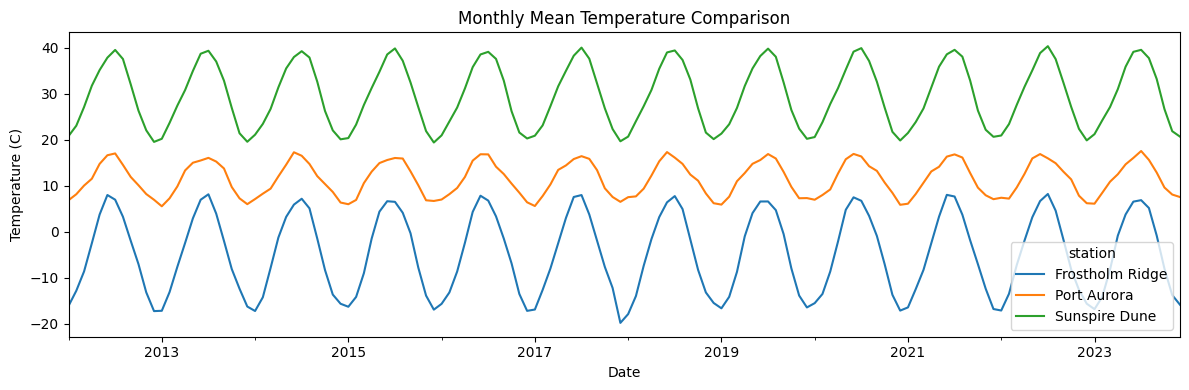

In [38]:
temperature_plot = monthly_summary.pivot(index="date", columns="station", values="temperature_c")
temperature_plot.plot(figsize=(12, 4))
plt.title("Monthly Mean Temperature Comparison")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.tight_layout()
plt.show()


## Plot monthly pressure


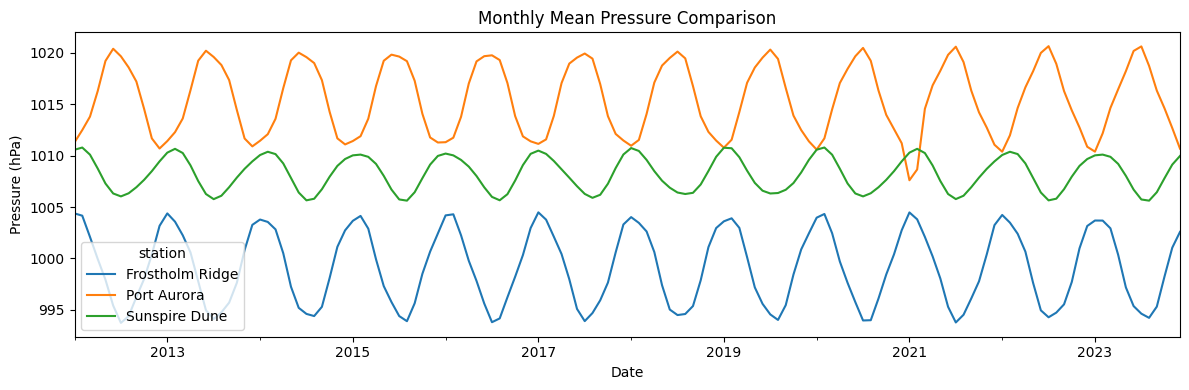

In [39]:
pressure_plot = monthly_summary.pivot(index="date", columns="station", values="pressure_hpa")
pressure_plot.plot(figsize=(12, 4))
plt.title("Monthly Mean Pressure Comparison")
plt.xlabel("Date")
plt.ylabel("Pressure (hPa)")
plt.tight_layout()
plt.show()


## Plot monthly rainfall


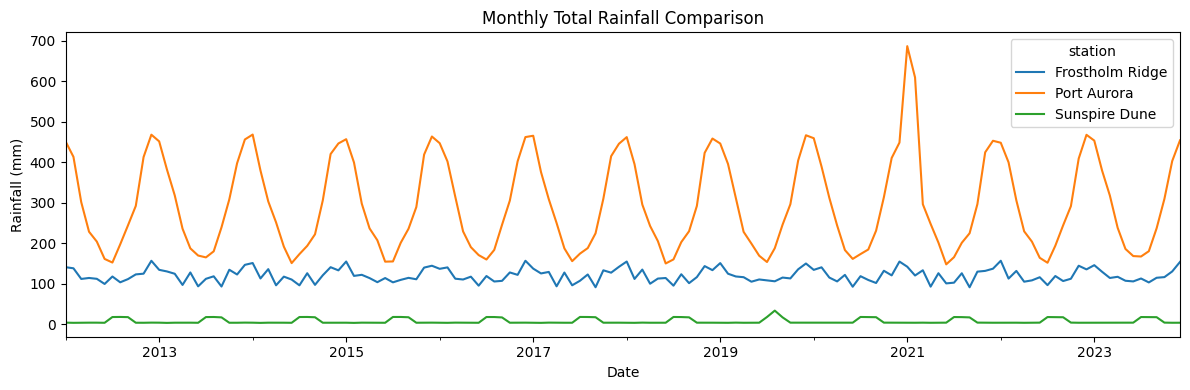

In [40]:
rain_plot = monthly_summary.pivot(index="date", columns="station", values="rain_mm")
rain_plot.plot(figsize=(12, 4))
plt.title("Monthly Total Rainfall Comparison")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()
